In [1]:
import urllib.request

url = "http://qim.fs.quoracdn.net/quora_duplicate_questions.tsv"

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0.0.0 Safari/537.36"}

req = urllib.request.Request(url, headers=headers)

with urllib.request.urlopen(req) as response:
    with open("quora_duplicate_questions.tsv", "wb") as f:
        f.write(response.read())

print("Download complete.")

Download complete.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("quora_duplicate_questions.tsv", sep="\t")
print(df.shape)   # (404290, 6)
df.head()

(404290, 6)


,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            404290 non-null  int64
 1   qid1          404290 non-null  int64
 2   qid2          404290 non-null  int64
 3   question1     404289 non-null  str  
 4   question2     404288 non-null  str  
 5   is_duplicate  404290 non-null  int64
dtypes: int64(4), str(2)
memory usage: 64.8 MB


In [4]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

is_duplicate
0    255027
1    149263
Name: count, dtype: int64
is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

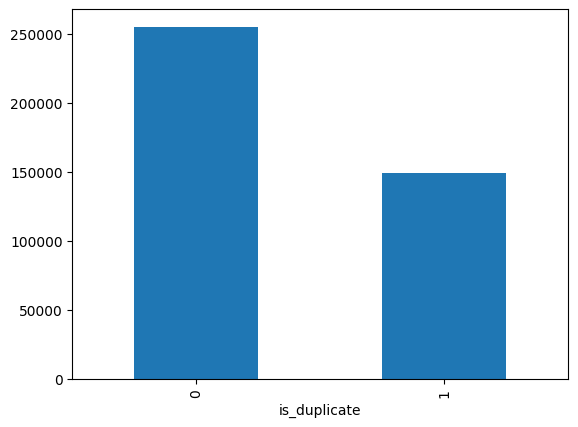

In [6]:
print(df['is_duplicate'].value_counts())
print(df['is_duplicate'].value_counts()/df['is_duplicate'].count()*100)
df['is_duplicate'].value_counts().plot(kind='bar')


In [7]:
qid=pd.Series(df['qid1'].tolist()+df['qid2'].tolist())
print("Number of unique questions",np.unique(qid).shape[0])
x=qid.value_counts()>1
print("Number of questions that are repeated",x[x].shape[0])

Number of unique questions 537933
Number of questions that are repeated 111780


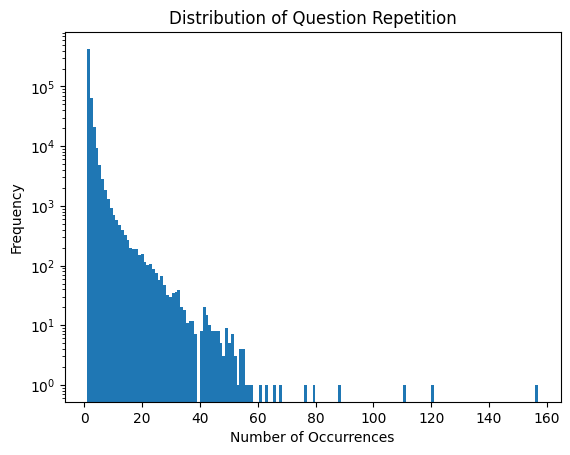

In [8]:
plt.hist(qid.value_counts().values, bins=160)
plt.xlabel("Number of Occurrences")
plt.ylabel("Frequency")
plt.title("Distribution of Question Repetition")
plt.yscale('log')  # Logarithmic scale for better visibility
plt.show()

In [9]:
new_df=df.sample(30000, random_state=42)

In [10]:
new_df.isnull().sum()   

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [11]:
new_df.duplicated().sum()

np.int64(0)

In [12]:
#Feature engineering
new_df['len_q1']=new_df['question1'].str.len()
new_df['len_q2']=new_df['question2'].str.len()

In [13]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,len_q1,len_q2
8067,8067,15738,15739,How do I play Pokémon GO in Korea?,How do I play Pokémon GO in China?,0,34,34
368101,368101,12736,104117,What are some of the best side dishes for crab...,What are some good side dishes for buffalo chi...,0,53,51
70497,70497,121486,121487,Which is more advisable and better material fo...,What is the best server setup for buddypress?,0,96,45
226567,226567,254474,258192,How do I improve logical programming skills?,How can I improve my logical skills for progra...,1,44,52
73186,73186,48103,3062,How close we are to see 3rd world war?,How close is a World War III?,1,38,29


In [14]:
new_df['q1_num_words']=new_df['question1'].apply(lambda x: len(x.split()))
new_df['q2_num_words']=new_df['question2'].apply(lambda x: len(x.split()))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,len_q1,len_q2,q1_num_words,q2_num_words
8067,8067,15738,15739,How do I play Pokémon GO in Korea?,How do I play Pokémon GO in China?,0,34,34,8,8
368101,368101,12736,104117,What are some of the best side dishes for crab...,What are some good side dishes for buffalo chi...,0,53,51,11,9
70497,70497,121486,121487,Which is more advisable and better material fo...,What is the best server setup for buddypress?,0,96,45,16,8
226567,226567,254474,258192,How do I improve logical programming skills?,How can I improve my logical skills for progra...,1,44,52,7,9
73186,73186,48103,3062,How close we are to see 3rd world war?,How close is a World War III?,1,38,29,9,7


In [15]:
def common_words(row):
    q1_words = set(map(lambda word: word.lower().strip(), row['question1'].split()))
    q2_words = set(map(lambda word: word.lower().strip(), row['question2'].split()))
    return len(q1_words.intersection(q2_words))

In [16]:
new_df['word_common']=new_df.apply(common_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,len_q1,len_q2,q1_num_words,q2_num_words,word_common
8067,8067,15738,15739,How do I play Pokémon GO in Korea?,How do I play Pokémon GO in China?,0,34,34,8,8,7
368101,368101,12736,104117,What are some of the best side dishes for crab...,What are some good side dishes for buffalo chi...,0,53,51,11,9,6
70497,70497,121486,121487,Which is more advisable and better material fo...,What is the best server setup for buddypress?,0,96,45,16,8,2
226567,226567,254474,258192,How do I improve logical programming skills?,How can I improve my logical skills for progra...,1,44,52,7,9,4
73186,73186,48103,3062,How close we are to see 3rd world war?,How close is a World War III?,1,38,29,9,7,3


In [17]:
def total_words(row):
    q1_words = set(map(lambda word: word.lower().strip(), row['question1'].split()))
    q2_words = set(map(lambda word: word.lower().strip(), row['question2'].split()))
    return len(q1_words.union(q2_words))

In [18]:
new_df['total_words']=new_df.apply(total_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,len_q1,len_q2,q1_num_words,q2_num_words,word_common,total_words
8067,8067,15738,15739,How do I play Pokémon GO in Korea?,How do I play Pokémon GO in China?,0,34,34,8,8,7,9
368101,368101,12736,104117,What are some of the best side dishes for crab...,What are some good side dishes for buffalo chi...,0,53,51,11,9,6,14
70497,70497,121486,121487,Which is more advisable and better material fo...,What is the best server setup for buddypress?,0,96,45,16,8,2,22
226567,226567,254474,258192,How do I improve logical programming skills?,How can I improve my logical skills for progra...,1,44,52,7,9,4,12
73186,73186,48103,3062,How close we are to see 3rd world war?,How close is a World War III?,1,38,29,9,7,3,13


In [19]:
new_df['word_share']=round(new_df['word_common']/new_df['total_words'],2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,len_q1,len_q2,q1_num_words,q2_num_words,word_common,total_words,word_share
8067,8067,15738,15739,How do I play Pokémon GO in Korea?,How do I play Pokémon GO in China?,0,34,34,8,8,7,9,0.78
368101,368101,12736,104117,What are some of the best side dishes for crab...,What are some good side dishes for buffalo chi...,0,53,51,11,9,6,14,0.43
70497,70497,121486,121487,Which is more advisable and better material fo...,What is the best server setup for buddypress?,0,96,45,16,8,2,22,0.09
226567,226567,254474,258192,How do I improve logical programming skills?,How can I improve my logical skills for progra...,1,44,52,7,9,4,12,0.33
73186,73186,48103,3062,How close we are to see 3rd world war?,How close is a World War III?,1,38,29,9,7,3,13,0.23


minimum characters 1
maximum characters 334
average characters 59.557966666666665


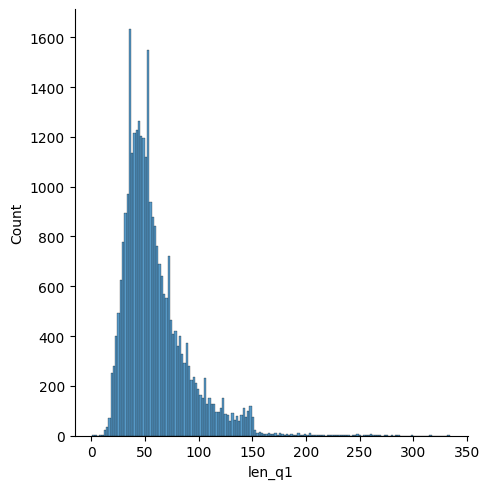

In [20]:
#analysis of features
sns.displot(new_df['len_q1'])
print('minimum characters',new_df['len_q1'].min())
print('maximum characters',new_df['len_q1'].max())
print('average characters',new_df['len_q1'].mean())

minimum characters 1
maximum characters 1169
average characters 59.7301


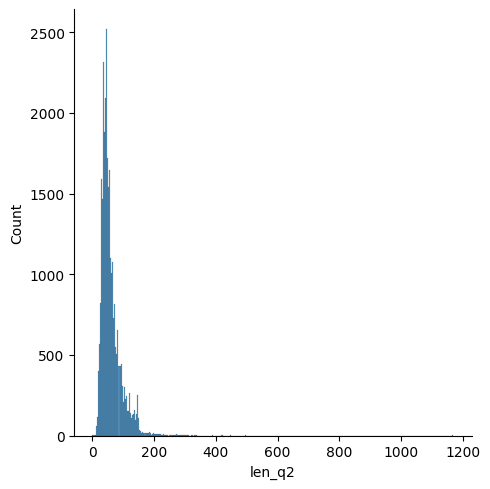

In [21]:
#analysis of features
sns.displot(new_df['len_q2'])
print('minimum characters',new_df['len_q2'].min())
print('maximum characters',new_df['len_q2'].max())
print('average characters',new_df['len_q2'].mean())

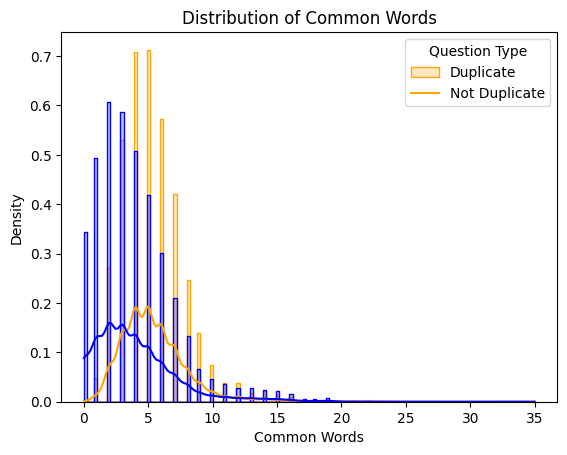

In [22]:
#common words
sns.histplot(
    data=new_df,
    x='word_common',
    hue='is_duplicate',
    kde=True,
    palette={0: 'blue', 1: 'orange'},
    element='step',
    stat='density',
    common_norm=False
)

plt.legend(title='Question Type', labels=['Duplicate', 'Not Duplicate'])
plt.xlabel('Common Words')
plt.ylabel('Density')
plt.title('Distribution of Common Words')
plt.show()

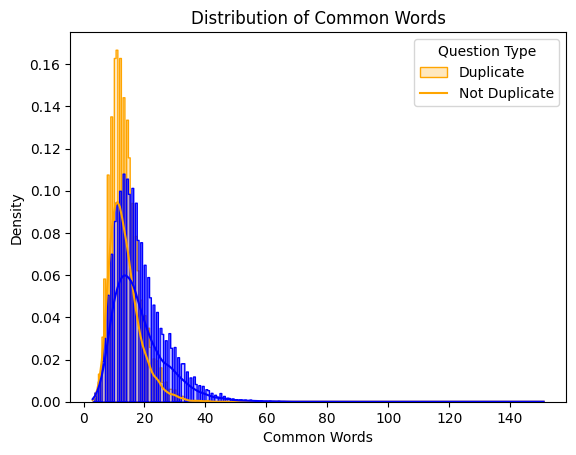

In [23]:
#total words
sns.histplot(
    data=new_df,
    x='total_words',
    hue='is_duplicate',
    kde=True,
    palette={0: 'blue', 1: 'orange'},
    element='step',
    stat='density',
    common_norm=False
)

plt.legend(title='Question Type', labels=['Duplicate', 'Not Duplicate'])
plt.xlabel('Common Words')
plt.ylabel('Density')
plt.title('Distribution of Common Words')
plt.show()

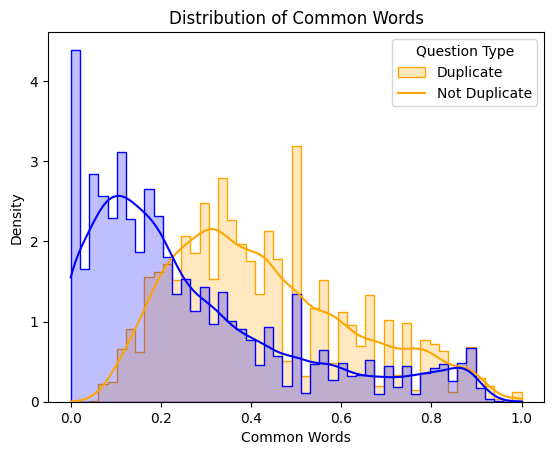

In [24]:
#total words
sns.histplot(
    data=new_df,
    x='word_share',
    hue='is_duplicate',
    kde=True,
    palette={0: 'blue', 1: 'orange'},
    element='step',
    stat='density',
    common_norm=False
)

plt.legend(title='Question Type', labels=['Duplicate', 'Not Duplicate'])
plt.xlabel('Common Words')
plt.ylabel('Density')
plt.title('Distribution of Common Words')
plt.show()

In [25]:
ques_df=new_df[['question1','question2']].copy()
ques_df.head()

,question1,question2
8067,How do I play Pokémon GO in Korea?,How do I play Pokémon GO in China?
368101,What are some of the best side dishes for crab...,What are some good side dishes for buffalo chi...
70497,Which is more advisable and better material fo...,What is the best server setup for buddypress?
226567,How do I improve logical programming skills?,How can I improve my logical skills for progra...
73186,How close we are to see 3rd world war?,How close is a World War III?


In [26]:
final_df=new_df.drop(['id','qid1','qid2','question1','question2'], axis=1)
final_df.head()

,is_duplicate,len_q1,len_q2,q1_num_words,q2_num_words,word_common,total_words,word_share
8067,0,34,34,8,8,7,9,0.78
368101,0,53,51,11,9,6,14,0.43
70497,0,96,45,16,8,2,22,0.09
226567,1,44,52,7,9,4,12,0.33
73186,1,38,29,9,7,3,13,0.23


In [27]:
from sklearn.feature_extraction.text import CountVectorizer
questions = ques_df['question1'].tolist() + ques_df['question2'].tolist()
cv = CountVectorizer(max_features=3000)
q1_arr,q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)
print(q1_arr.shape)

(30000, 3000)


In [28]:
temp_df1=pd.DataFrame(q1_arr, index=ques_df.index)
temp_df2=pd.DataFrame(q2_arr, index=ques_df.index)
temp_df=pd.concat([temp_df1,temp_df2], axis=1)
temp_df.shape

(30000, 6000)

In [29]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
8067,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
368101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
70497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
226567,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
73186,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81275,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
273382,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
142371,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
79120,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
final_df=pd.concat([final_df,temp_df], axis=1)
print(final_df.shape)
final_df.head()

(30000, 6008)


,is_duplicate,len_q1,len_q2,q1_num_words,q2_num_words,word_common,total_words,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
8067,0,34,34,8,8,7,9,0.78,0,0,...,0,0,0,0,0,0,0,0,0,0
368101,0,53,51,11,9,6,14,0.43,0,0,...,0,0,0,0,0,0,0,0,0,0
70497,0,96,45,16,8,2,22,0.09,0,0,...,0,0,0,0,0,0,0,0,0,0
226567,1,44,52,7,9,4,12,0.33,0,0,...,0,0,0,0,0,0,0,0,0,0
73186,1,38,29,9,7,3,13,0.23,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
temp_df['is_duplicate']=new_df['is_duplicate']
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
8067,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
368101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
70497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
226567,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
73186,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [32]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(temp_df.iloc[:, :-1].values, temp_df.iloc[:, -1].values, test_size=0.2, random_state=42)

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier()
rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7483333333333333


In [34]:
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(x_train,y_train)
y_pred_xgb = xgb.predict(x_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", accuracy_xgb)

XGBoost Accuracy: 0.7456666666666667
